<a href="https://colab.research.google.com/github/suranimayur/Advance-Seaborn-for-Data-Visualization-End-to-End-Implementation-Guide-Template/blob/main/End_to_end_TimeSeries_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from math import sqrt
from statsmodels.tsa.arima.model import ARIMA

### Generate Time Series Data

In [5]:
np.random.seed(10)
date_range = pd.date_range(start='1/1/2020',periods=300,freq='D')
data = np.random.randn(300).cumsum() + 50

time_series_data = pd.Series(data,index=date_range)

## Plot the time series

Text(0, 0.5, 'Value')

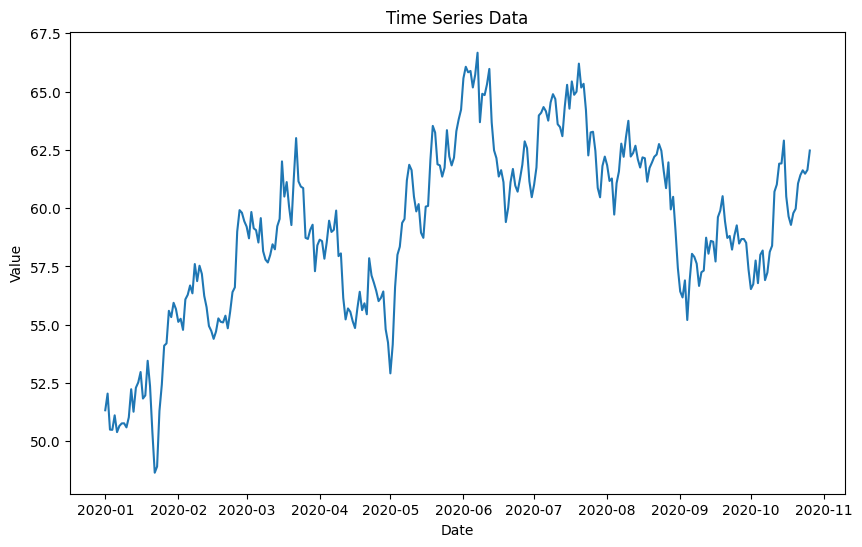

In [6]:
plt.figure(figsize=(10,6))
plt.plot(time_series_data)
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Value')

## Test for Stationarity



In [10]:
def test_stationarity(timeseries):
  result = adfuller(timeseries)
  print('ADF Statistic: %f' % result[0])
  print("p-value:- ",result[1])

  if result[1] > 0.05:
    print("Reject null hypothesis and Series is not Stationary")
  else:
    print("Fail to reject null hypothesis and Series is Stationary")

In [11]:
test_stationarity(time_series_data)

ADF Statistic: -2.614770
p-value:-  0.08998294769573939
Reject null hypothesis and Series is not Stationary


## Differencing to make series stationaries

In [12]:
time_series_diff = time_series_data.diff().dropna()
test_stationarity(time_series_diff)

ADF Statistic: -17.325834
p-value:-  5.446857481832121e-30
Fail to reject null hypothesis and Series is Stationary


## Decompose the time series stationary


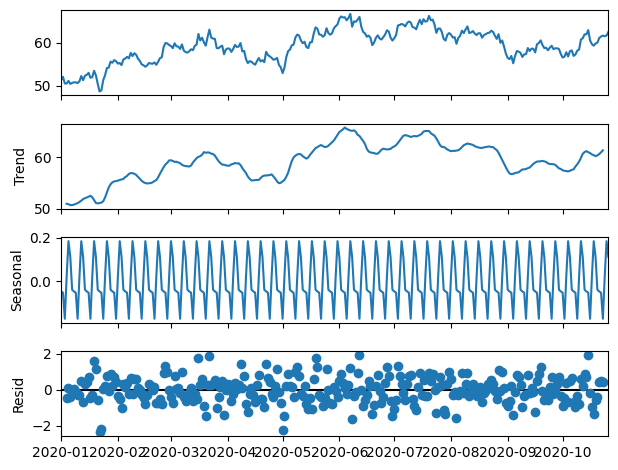

In [13]:
decomposition = seasonal_decompose(time_series_data,model='additive')
decomposition.plot()
plt.show()

## Fit ARIMA Model

In [16]:
model = ARIMA(time_series_data,order=(1,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  300
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -410.886
Date:                Sat, 07 Sep 2024   AIC                            827.772
Time:                        01:37:17   BIC                            838.874
Sample:                    01-01-2020   HQIC                           832.216
                         - 10-26-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0030      9.826     -0.000      1.000     -19.262      19.256
ma.L1         -0.0030      9.825     -0.000      1.000     -19.260      19.254
sigma2         0.9144      0.072     12.639      0.0

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


## Forecast

In [19]:
 forecast = model_fit.forecast(steps=10)
 print("Forecasted values :",forecast)

Forecasted values : 2020-10-27    62.465854
2020-10-28    62.465869
2020-10-29    62.465869
2020-10-30    62.465869
2020-10-31    62.465869
2020-11-01    62.465869
2020-11-02    62.465869
2020-11-03    62.465869
2020-11-04    62.465869
2020-11-05    62.465869
Freq: D, Name: predicted_mean, dtype: float64


## Evaluate the model

In [21]:
train_size = int(len(time_series_data)*0.8)
train,test = time_series_data[0:train_size],time_series_data[train_size:]

model = ARIMA(train,order=(1,1,1))
model_fit = model.fit()

predictions = model_fit.predict(start=len(train),end=len(train)+len(test)-1,typ='levels')
rmse = sqrt(mean_squared_error(test,predictions))
print("RMSE: %.3f " % rmse)

RMSE: 3.638 


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


## Plot predictions vs actual

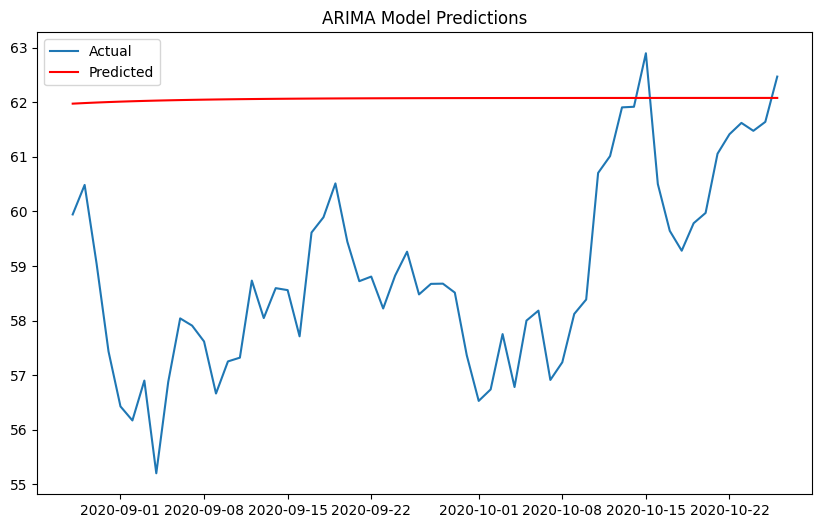

In [22]:
plt.figure(figsize=(10,6))
plt.plot(test.index,test,label='Actual')
plt.plot(test.index,predictions,label='Predicted',color='red')
plt.title("ARIMA Model Predictions")
plt.legend()
plt.show()

                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                  300
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -412.349
Date:                            Sat, 07 Sep 2024   AIC                            834.699
Time:                                    01:49:56   BIC                            852.996
Sample:                                01-01-2020   HQIC                           842.032
                                     - 10-26-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9028      0.105      8.590      0.000       0.697       1.109
ma.L1         -0.9441      0.086   

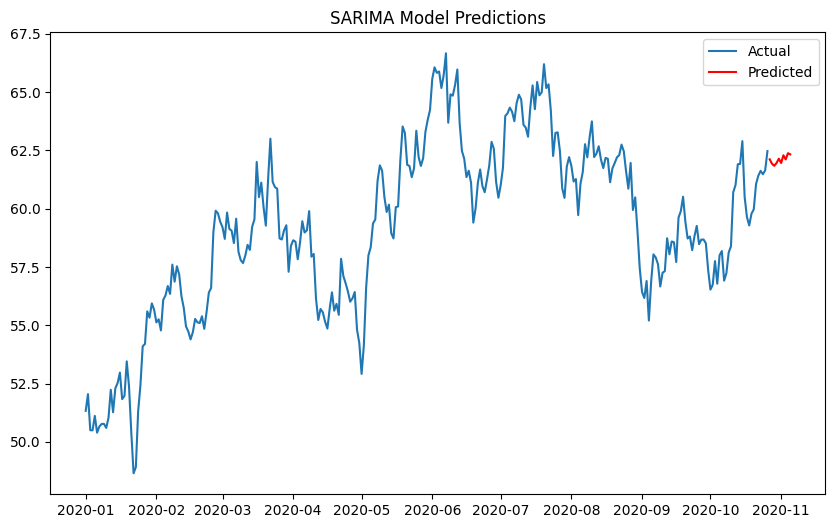

In [27]:
## Fit SARIMA Model


sarima_model = SARIMAX(time_series_data,order=(1,1,1),seasonal_order=(1,1,1,12))
sarima_model_fit = sarima_model.fit()
print(sarima_model_fit.summary())


# Forecast with SARIMA

sarima_forecast = sarima_model_fit.forecast(steps=10)
print("Forecasted values :",sarima_forecast)

# Plot SARIMA Prediction

plt.figure(figsize=(10,6))
plt.plot(time_series_data.index,time_series_data,label='Actual')
plt.plot(pd.date_range(start=time_series_data.index[-1],periods=11,freq='D')[1:],
         sarima_forecast,label='Predicted',color='red')
plt.title("SARIMA Model Predictions")
plt.legend()
plt.show()